In [1]:
import sys, importlib
from pathlib import Path

src_path = str(Path("../src").resolve())
sys.path.insert(0, src_path)

for name in ["clustering", "get_event", "hits_cut", "write_h5"]:
    if name in sys.modules:
        del sys.modules[name]

import clustering
import get_event as event
import hits_cut as filters
import write_h5 as h5

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from collections import defaultdict
import numpy as np
import h5py

In [3]:
path1 = "/global/cfs/cdirs/dune/www/data/2x2/sandbox/v11/flow/packet-0050017-2024_07_09_00_04_33_CDT.FLOW.hdf5"
path2 = "/global/cfs/cdirs/dune/www/data/2x2/sandbox/v11/flow/packet-0050017-2024_07_09_00_14_34_CDT.FLOW.hdf5"
path3 = "/global/cfs/cdirs/dune/www/data/2x2/sandbox/v11/flow/packet-0050017-2024_07_09_00_24_35_CDT.FLOW.hdf5"
path4 = "/global/cfs/cdirs/dune/www/data/2x2/sandbox/v11/flow/packet-0050017-2024_07_09_00_34_36_CDT.FLOW.hdf5"
path5 = "/global/cfs/cdirs/dune/www/data/2x2/sandbox/v11/flow/packet-0050017-2024_07_09_00_44_37_CDT.FLOW.hdf5"
path6 = "/global/cfs/cdirs/dune/www/data/2x2/sandbox/v11/flow/packet-0050017-2024_07_09_00_54_38_CDT.FLOW.hdf5"
paths = [path1,path2,path3,path4,path5,path6,]

In [4]:
pixel_occupancy=event.build_occupancy(paths, level="pixel")
chip_occupancy=event.build_occupancy(paths, level="chip")

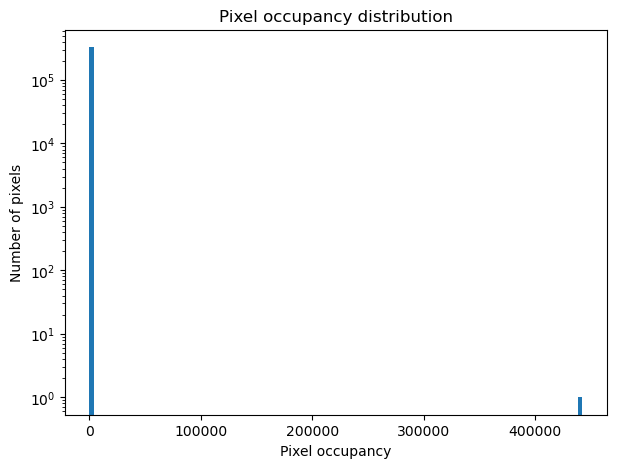

In [5]:
occ = np.array(list(pixel_occupancy.values()))

plt.figure(figsize=(7,5))
plt.hist(occ, bins=100)
plt.yscale("log")
plt.xlabel("Pixel occupancy")
plt.ylabel("Number of pixels")
plt.title("Pixel occupancy distribution")
plt.show()

### loose cut 0.1%

In [6]:
print("pixel cut: ")
occ_pixel_left, pixel_keys = filters.device_hits_cut(pixel_occupancy, 0.99)
print("chip cut: ")
occ_chip_left, chip_keys = filters.device_hits_cut(chip_occupancy, 0.99)

pixel cut: 
total: 327269
left : 323996
removed: 3273
total hits: 7077828
hits left: 6191123
hits removed: 886705
hits lost: 12.53%
chip cut: 
total: 6824
left : 6755
removed: 69
total hits: 7077828
hits left: 6473357
hits removed: 604471
hits lost: 8.54%


In [13]:
all_clusters = []
#TEST_N = 200
global_evt_idx = 0

for file_idx, path in enumerate(paths):

    with h5py.File(path, "r") as f:
        n_events = len(f["charge/events/data"])
        #n_events = min(len(f["charge/events/data"]), TEST_N)
        for local_evt_idx in range(n_events):

            hits = event.get_event_hits_by_event_index(f, local_evt_idx)
            beam_type = event.get_beam_type(f, local_evt_idx)

            hits = filters.fiducial_cut(hits)
            if len(hits) == 0:
                global_evt_idx += 1
                continue
            hits, _ = filters.hot_region_cut(hits, chip_keys, pixel_keys)
            if len(hits) == 0:
                global_evt_idx += 1
                continue
            hits, _ = filters.repeated_pixel_cut(hits, min_count=3)
            if len(hits) == 0:
                global_evt_idx += 1
                continue
            clusters, labels = clustering.build_clusters(hits)
            clusters_keep, clusters_remove = clustering.remove_clusters_near_track_points(clusters,R_cut=15.0,target_labels=("track", "shower"))
            if len(clusters_keep) > 10:
                for c in clusters_keep:
                    c["type"] = "removed"
                for c in clusters_remove:
                    c["type"] = "removed"
                clusters_final = clusters_keep + clusters_remove
            else:
                clusters_keep = clustering.assign_cluster_type(clusters_keep)
                for c in clusters_remove:
                    c["type"] = "removed"
                clusters_final = clusters_keep + clusters_remove
            clusters_final = filters.two_blip_min_distance_cut(clusters_final,d_min=10.0)
            for c in clusters_final:
                c["file_idx"] = file_idx
                c["path"] = path
                c["evt_idx"] = global_evt_idx
                c["local_evt_idx"] = local_evt_idx
                c["beam_type"] = beam_type
                all_clusters.append(c)
            global_evt_idx += 1

In [14]:
out_path = "../data/real_data_pixel_1_min_dist_10.h5"
h5.save_normal_hits(all_clusters, out_path, global_evt_idx)
#h5.save_normal_hits(all_clusters, "../data/test_normal_hits_d20.h5",  global_evt_idx)

saved: ../data/real_data_pixel_1_min_dist_10.h5
total events: 55876
events with normal hits: 39042
total normal hits: 115552
